# IMC Prosperity 4 Research Notebook

Use this notebook as the main workflow:
1. Put CSVs in `data/raw/`
2. Run the setup cell
3. Inspect price files first
4. Diagnose product behavior
5. Translate findings into `trader.py`


## 0. Setup
This cell sets paths and imports.

In [1]:
# IMC Prosperity 4 Research Notebook - Round 1 Focus

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PROJECT_ROOT = r"C:\Users\RiceC\Prosperity4"
DATA_FOLDER = os.path.join(PROJECT_ROOT, "data", "raw")
ROUND1_FOLDER = os.path.join(DATA_FOLDER, "round1")
OUTPUT_FOLDER = os.path.join(PROJECT_ROOT, "output", "plots")

os.makedirs(DATA_FOLDER, exist_ok=True)
os.makedirs(ROUND1_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ROUND1_FOLDER:", ROUND1_FOLDER)
print("OUTPUT_FOLDER:", OUTPUT_FOLDER)


PROJECT_ROOT: C:\Users\RiceC\Prosperity4
ROUND1_FOLDER: C:\Users\RiceC\Prosperity4\data\raw\round1
OUTPUT_FOLDER: C:\Users\RiceC\Prosperity4\output\plots


## 1. Discover files

In [2]:
# Discover files in round1 folder
allFiles = sorted([f for f in os.listdir(ROUND1_FOLDER) if f.endswith(".csv")])
priceFiles = [f for f in allFiles if f.startswith("prices_")]
tradeFiles = [f for f in allFiles if f.startswith("trades_")]

print("Price files:")
for f in priceFiles:
    print(" -", f)

print("\nTrade files:")
for f in tradeFiles:
    print(" -", f)

Price files:
 - prices_round_1_day_-1.csv
 - prices_round_1_day_-2.csv
 - prices_round_1_day_0.csv

Trade files:
 - trades_round_1_day_-1.csv
 - trades_round_1_day_-2.csv
 - trades_round_1_day_0.csv


## 2. Load all Round 1 price CSVs
This version auto-discovers every Round 1 price file in the folder, tags rows with `fileName` and `day`,
and builds one combined dataframe so you can compare day -2 / -1 / 0 without editing filenames by hand.


In [3]:
# Load all Round 1 price CSVs
roundPattern = re.compile(r"prices_round_(?P<round>\d+)_day_(?P<day>-?\d+)\.csv$")

def parseDayFromFilename(fileName):
    match = roundPattern.match(fileName)
    return int(match.group("day")) if match else np.nan

round1PriceFiles = []
for f in sorted(os.listdir(ROUND1_FOLDER)):
    if f.endswith(".csv") and f.startswith("prices_"):
        match = roundPattern.match(f)
        if match and int(match.group("round")) == 1:
            round1PriceFiles.append(f)

if not round1PriceFiles:
    raise FileNotFoundError(
        f"No Round 1 price files found in {ROUND1_FOLDER}. "
        "Expected names like prices_round_1_day_-2.csv, prices_round_1_day_-1.csv, prices_round_1_day_0.csv."
    )

priceDataByFile = {}
priceMetaRows = []

for fileName in round1PriceFiles:
    filePath = os.path.join(ROUND1_FOLDER, fileName)
    tmp = pd.read_csv(filePath, sep=";")
    tmp["fileName"] = fileName
    tmp["day"] = parseDayFromFilename(fileName)

    priceDataByFile[fileName] = tmp
    priceMetaRows.append({
        "fileName": fileName,
        "day": parseDayFromFilename(fileName),
        "rows": len(tmp),
        "products": ", ".join(map(str, sorted(tmp["product"].dropna().unique()))) if "product" in tmp.columns else "",
        "timestamp_min": tmp["timestamp"].min() if "timestamp" in tmp.columns else np.nan,
        "timestamp_max": tmp["timestamp"].max() if "timestamp" in tmp.columns else np.nan,
    })

priceMetaDf = pd.DataFrame(priceMetaRows).sort_values(["day", "fileName"]).reset_index(drop=True)
combinedRawDf = pd.concat([priceDataByFile[f] for f in round1PriceFiles], ignore_index=True)

print("Loaded Round 1 price files:")
display(priceMetaDf)

print("\nCombined raw shape:", combinedRawDf.shape)
print("Combined columns:")
print(combinedRawDf.columns.tolist())


Loaded Round 1 price files:


,fileName,day,rows,products,timestamp_min,timestamp_max
0,prices_round_1_day_-2.csv,-2,20000,"ASH_COATED_OSMIUM, INTARIAN_PEPPER_ROOT",0,999900
1,prices_round_1_day_-1.csv,-1,20000,"ASH_COATED_OSMIUM, INTARIAN_PEPPER_ROOT",0,999900
2,prices_round_1_day_0.csv,0,20000,"ASH_COATED_OSMIUM, INTARIAN_PEPPER_ROOT",0,999900



Combined raw shape: (60000, 18)
Combined columns:
['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss', 'fileName']


## 3. Basic dataset inspection
Start by checking that every expected price file loaded correctly.


In [4]:
# Basic inspection by file
inspectionRows = []

for fileName in round1PriceFiles:
    df0 = priceDataByFile[fileName]

    row = {
        "fileName": fileName,
        "day": parseDayFromFilename(fileName),
        "rows": len(df0),
        "products_n": df0["product"].nunique() if "product" in df0.columns else np.nan,
        "products": ", ".join(map(str, sorted(df0["product"].dropna().unique()))) if "product" in df0.columns else "",
        "timestamp_min": df0["timestamp"].min() if "timestamp" in df0.columns else np.nan,
        "timestamp_max": df0["timestamp"].max() if "timestamp" in df0.columns else np.nan,
        "best_bid_missing_pct": df0["bid_price_1"].isna().mean() if "bid_price_1" in df0.columns else np.nan,
        "best_ask_missing_pct": df0["ask_price_1"].isna().mean() if "ask_price_1" in df0.columns else np.nan,
    }
    inspectionRows.append(row)

inspectionDf = pd.DataFrame(inspectionRows).sort_values(["day", "fileName"]).reset_index(drop=True)
inspectionDf


,fileName,day,rows,products_n,products,timestamp_min,timestamp_max,best_bid_missing_pct,best_ask_missing_pct
0,prices_round_1_day_-2.csv,-2,20000,2,"ASH_COATED_OSMIUM, INTARIAN_PEPPER_ROOT",0,999900,0.04130,0.04025
1,prices_round_1_day_-1.csv,-1,20000,2,"ASH_COATED_OSMIUM, INTARIAN_PEPPER_ROOT",0,999900,0.04065,0.03885
2,prices_round_1_day_0.csv,0,20000,2,"ASH_COATED_OSMIUM, INTARIAN_PEPPER_ROOT",0,999900,0.03905,0.03845


## 4. Build first-pass features
This is the core diagnostic layer.

Important changes:
- features are built per `(fileName, product)` so timestamps resetting across days do not break the analysis
- all price files are analyzed together
- helper functions are defined once so later cells stay short


In [5]:
# Helper functions + feature engineering

def build_features(inputDf, groupCols=("fileName", "product")):
    work = inputDf.copy().sort_values(list(groupCols) + ["timestamp"]).reset_index(drop=True)

    bidPriceCols = [c for c in work.columns if c.startswith("bid_price_")]
    askPriceCols = [c for c in work.columns if c.startswith("ask_price_")]

    # Safe best bid / ask
    work["bestBid"] = work["bid_price_1"] if "bid_price_1" in work.columns else np.nan
    work["bestAsk"] = work["ask_price_1"] if "ask_price_1" in work.columns else np.nan

    # Treat non-positive prices as missing if they appear
    work["bestBid"] = work["bestBid"].where(work["bestBid"] > 0, np.nan)
    work["bestAsk"] = work["bestAsk"].where(work["bestAsk"] > 0, np.nan)

    # Robust mid:
    # - use normal mid if both sides exist
    # - otherwise fall back to whichever side exists
    # - then forward-fill within each (fileName, product)
    midBoth = (work["bestBid"] + work["bestAsk"]) / 2.0
    midOneSided = work["bestBid"].combine_first(work["bestAsk"])
    work["midPriceRaw"] = midBoth.combine_first(midOneSided)
    work["midPrice"] = work.groupby(list(groupCols))["midPriceRaw"].ffill()

    # Spread only when both sides exist
    work["spread"] = work["bestAsk"] - work["bestBid"]

    # Returns / rolling stats
    work["return1"] = work.groupby(list(groupCols))["midPrice"].diff()
    work["return2"] = work.groupby(list(groupCols))["midPrice"].diff(2)
    work["rollingMean20"] = work.groupby(list(groupCols))["midPrice"].transform(lambda s: s.rolling(20, min_periods=20).mean())
    work["rollingStd20"] = work.groupby(list(groupCols))["midPrice"].transform(lambda s: s.rolling(20, min_periods=20).std())
    work["zScore20"] = (work["midPrice"] - work["rollingMean20"]) / work["rollingStd20"]
    work["momentum5"] = work.groupby(list(groupCols))["midPrice"].transform(lambda s: s - s.shift(5))
    work["momentum10"] = work.groupby(list(groupCols))["midPrice"].transform(lambda s: s - s.shift(10))
    work["nextReturn1"] = work.groupby(list(groupCols))["return1"].shift(-1)

    # Wall view
    if bidPriceCols:
        work["bidWall"] = work[bidPriceCols].replace(0, np.nan).min(axis=1)
    if askPriceCols:
        work["askWall"] = work[askPriceCols].replace(0, np.nan).max(axis=1)
    if "bidWall" in work.columns and "askWall" in work.columns:
        work["wallMid"] = (work["bidWall"] + work["askWall"]) / 2.0

    # Imbalance / microprice only when both top levels exist
    if "bid_volume_1" in work.columns and "ask_volume_1" in work.columns:
        totalVol = work["bid_volume_1"].abs() + work["ask_volume_1"].abs()
        work["imbalance"] = np.where(
            totalVol != 0,
            (work["bid_volume_1"].abs() - work["ask_volume_1"].abs()) / totalVol,
            np.nan,
        )
        work["microprice"] = np.where(
            totalVol != 0,
            (
                work["bestAsk"] * work["bid_volume_1"].abs()
                + work["bestBid"] * work["ask_volume_1"].abs()
            ) / totalVol,
            np.nan,
        )

    work["hasBothSides"] = work["bestBid"].notna() & work["bestAsk"].notna()
    if "wallMid" in work.columns:
        work["midMinusWallMid"] = work["midPrice"] - work["wallMid"]

    return work


def summarize_one_product(productDf):
    row = {
        "rows": len(productDf),
        "mid_mean": productDf["midPrice"].mean(),
        "mid_std": productDf["midPrice"].std(),
        "spread_mean": productDf["spread"].mean(),
        "spread_std": productDf["spread"].std(),
        "ret_autocorr_1": productDf["return1"].autocorr(lag=1),
        "ret_autocorr_2": productDf["return1"].autocorr(lag=2),
        "mom5_next_ret_corr": productDf["momentum5"].corr(productDf["nextReturn1"]),
        "mom10_next_ret_corr": productDf["momentum10"].corr(productDf["nextReturn1"]),
    }

    if "imbalance" in productDf.columns:
        row["imbalance_next_return_corr"] = productDf["imbalance"].corr(productDf["nextReturn1"])

    if "wallMid" in productDf.columns:
        row["wall_mid_diff_std"] = (productDf["midPrice"] - productDf["wallMid"]).std()
        row["wall_mid_next_ret_corr"] = (productDf["midPrice"] - productDf["wallMid"]).corr(productDf["nextReturn1"])

    return row


def add_regression_fairs(productDf, windows=(50, 100, 150)):
    out = productDf.copy().sort_values("timestamp").reset_index(drop=True)
    mids = out["midPrice"].to_numpy()

    for window in windows:
        regFairs = [np.nan] * len(out)
        regSlopes = [np.nan] * len(out)

        for i in range(window, len(out)):
            y = mids[i - window:i]
            x = np.arange(window)

            xMean = x.mean()
            yMean = y.mean()

            num = ((x - xMean) * (y - yMean)).sum()
            den = ((x - xMean) ** 2).sum()
            slope = 0 if den == 0 else num / den
            intercept = yMean - slope * xMean

            regFairs[i] = slope * (window - 1) + intercept
            regSlopes[i] = slope

        out[f"regFair{window}"] = regFairs
        out[f"regResidual{window}"] = out["midPrice"] - out[f"regFair{window}"]
        out[f"regSlope{window}"] = regSlopes
        out[f"regResidualStd{window}"] = out[f"regResidual{window}"].rolling(100, min_periods=30).std()
        out[f"regResidualZ{window}"] = out[f"regResidual{window}"] / out[f"regResidualStd{window}"]

    return out


def fair_candidates_for_product(productDf, product, pepperFramesByFile=None, fileName=None):
    fairs = {"midPrice": productDf["midPrice"]}

    if "rollingMean20" in productDf.columns:
        fairs["rollingMean20"] = productDf["rollingMean20"]

    if "wallMid" in productDf.columns and productDf["wallMid"].notna().any():
        fairs["wallMid"] = productDf["wallMid"]

    if "microprice" in productDf.columns and productDf["microprice"].notna().any():
        fairs["microprice"] = productDf["microprice"]

    if (
        product == "INTARIAN_PEPPER_ROOT"
        and pepperFramesByFile is not None
        and fileName in pepperFramesByFile
        and "regFair100" in pepperFramesByFile[fileName].columns
    ):
        regDf = pepperFramesByFile[fileName][["timestamp", "regFair100"]]
        tmp = productDf[["timestamp"]].merge(regDf, on="timestamp", how="left")
        fairs["regFair100"] = tmp["regFair100"]

    return fairs


allWork = build_features(combinedRawDf, groupCols=("fileName", "product"))
print("Feature dataframe shape:", allWork.shape)
allWork.head()


Feature dataframe shape: (60000, 38)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,fileName,bestBid,bestAsk,midPriceRaw,midPrice,spread,return1,return2,rollingMean20,rollingStd20,zScore20,momentum5,momentum10,nextReturn1,bidWall,askWall,wallMid,imbalance,microprice,hasBothSides,midMinusWallMid
0,-1,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10003.0,29.0,NaN,NaN,NaN,NaN,10003.0,0.0,prices_round_1_day_-1.csv,NaN,10003.0,10003.0,10003.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-11.0,NaN,10003.0,NaN,NaN,NaN,False,NaN
1,-1,100,ASH_COATED_OSMIUM,9984.0,11.0,NaN,NaN,NaN,NaN,10000.0,11.0,10003.0,22.0,NaN,NaN,9992.0,0.0,prices_round_1_day_-1.csv,9984.0,10000.0,9992.0,9992.0,16.0,-11.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,9984.0,10003.0,9993.5,0.0,9992.0,True,-1.5
2,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,20.0,NaN,NaN,10001.0,15.0,10003.0,20.0,NaN,NaN,9993.0,0.0,prices_round_1_day_-1.csv,9985.0,10001.0,9993.0,9993.0,16.0,1.0,-10.0,NaN,NaN,NaN,NaN,NaN,0.0,9982.0,10003.0,9992.5,0.0,9993.0,True,0.5
3,-1,300,ASH_COATED_OSMIUM,9985.0,11.0,9982.0,29.0,NaN,NaN,10001.0,11.0,10003.0,29.0,NaN,NaN,9993.0,0.0,prices_round_1_day_-1.csv,9985.0,10001.0,9993.0,9993.0,16.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,0.0,9982.0,10003.0,9992.5,0.0,9993.0,True,0.5
4,-1,400,ASH_COATED_OSMIUM,9985.0,12.0,NaN,NaN,NaN,NaN,10001.0,12.0,10004.0,25.0,NaN,NaN,9993.0,0.0,prices_round_1_day_-1.csv,9985.0,10001.0,9993.0,9993.0,16.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,9985.0,10004.0,9994.5,0.0,9993.0,True,-1.5


## 5. Product summary
You now get:
- one summary row per `(day, product)`
- one combined summary row per `product` across all loaded Round 1 files


In [6]:
# Product summary by day and combined
summaryRows = []

for (fileName, day, product), productDf in allWork.groupby(["fileName", "day", "product"], sort=True):
    row = {
        "fileName": fileName,
        "day": day,
        "product": product,
    }
    row.update(summarize_one_product(productDf.sort_values("timestamp")))
    summaryRows.append(row)

summaryByFileProduct = pd.DataFrame(summaryRows).sort_values(["product", "day", "fileName"]).reset_index(drop=True)

combinedSummaryRows = []
for product, productDf in allWork.groupby("product", sort=True):
    row = {
        "product": product,
        "scope": "ALL_LOADED_FILES",
    }
    row.update(summarize_one_product(productDf.sort_values(["fileName", "timestamp"])))
    combinedSummaryRows.append(row)

summaryCombinedByProduct = pd.DataFrame(combinedSummaryRows).sort_values("product").reset_index(drop=True)

print("Per-day summary:")
display(summaryByFileProduct)

print("\nCombined summary across all loaded Round 1 files:")
display(summaryCombinedByProduct)


Per-day summary:


,fileName,day,product,rows,mid_mean,mid_std,spread_mean,spread_std,ret_autocorr_1,ret_autocorr_2,mom5_next_ret_corr,mom10_next_ret_corr,imbalance_next_return_corr,wall_mid_diff_std,wall_mid_next_ret_corr
0,prices_round_1_day_-2.csv,-2,ASH_COATED_OSMIUM,10000,9998.17375,5.220231,16.149777,2.538189,-0.498808,0.011400,-0.495708,-0.482113,0.371805,1.428428,-0.368225
1,prices_round_1_day_-1.csv,-1,ASH_COATED_OSMIUM,10000,10000.83690,4.449099,16.191328,2.555484,-0.497211,-0.001686,-0.492117,-0.488888,0.391263,1.438973,-0.386616
2,prices_round_1_day_0.csv,0,ASH_COATED_OSMIUM,10000,10001.60750,5.684578,16.184467,2.618544,-0.487015,-0.015297,-0.483272,-0.482533,0.379342,1.465132,-0.401063
3,prices_round_1_day_-2.csv,-2,INTARIAN_PEPPER_ROOT,10000,10499.94360,288.704234,11.994792,2.264730,-0.495220,-0.003135,-0.500182,-0.498344,0.371918,1.240460,-0.379577
4,prices_round_1_day_-1.csv,-1,INTARIAN_PEPPER_ROOT,10000,11499.95280,288.720072,13.012257,2.487626,-0.493938,-0.003979,-0.492436,-0.495854,0.393728,1.371049,-0.390641
5,prices_round_1_day_0.csv,0,INTARIAN_PEPPER_ROOT,10000,12499.94190,288.722244,14.128715,2.665688,-0.507818,0.019847,-0.495986,-0.493265,0.388654,1.470062,-0.397183



Combined summary across all loaded Round 1 files:


,product,scope,rows,mid_mean,mid_std,spread_mean,spread_std,ret_autocorr_1,ret_autocorr_2,mom5_next_ret_corr,mom10_next_ret_corr,imbalance_next_return_corr,wall_mid_diff_std,wall_mid_next_ret_corr
0,ASH_COATED_OSMIUM,ALL_LOADED_FILES,30000,10000.20605,5.349359,16.175228,2.570999,-0.494420,-0.001906,-0.490435,-0.484478,0.380803,1.444425,-0.385384
1,INTARIAN_PEPPER_ROOT,ALL_LOADED_FILES,30000,11499.94610,866.047833,13.046699,2.627145,-0.499637,0.005455,-0.495929,-0.495549,0.384362,1.363879,-0.390153


## 6. Plot one selected day
Set `plotFileName` below and rerun this cell to inspect a specific day in detail.


Plotting: prices_round_1_day_0.csv


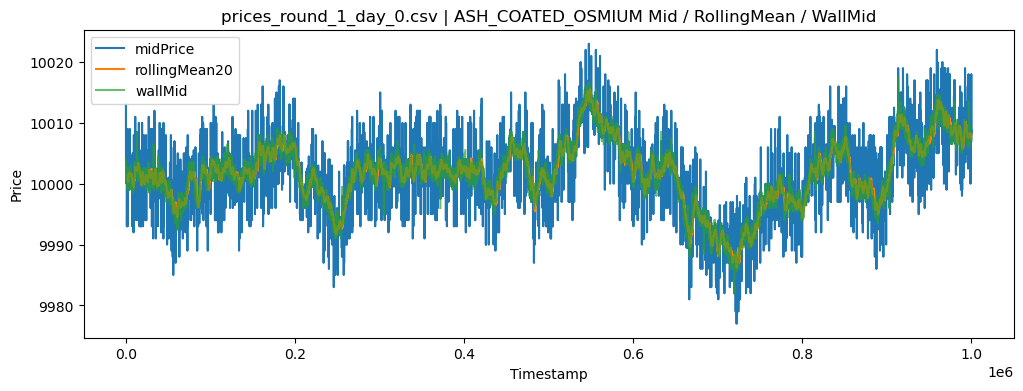

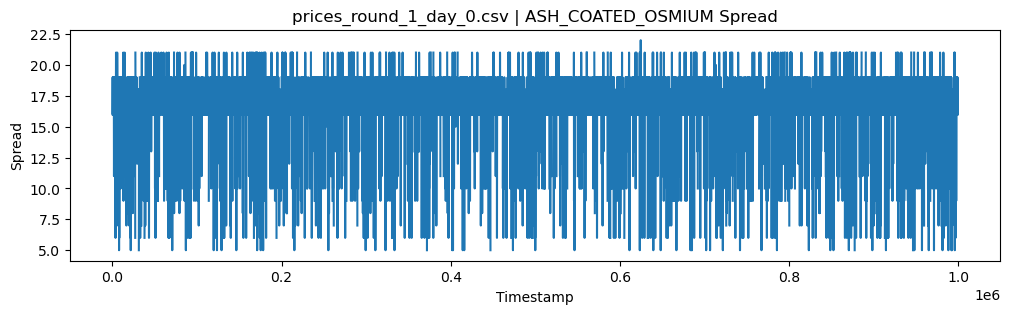

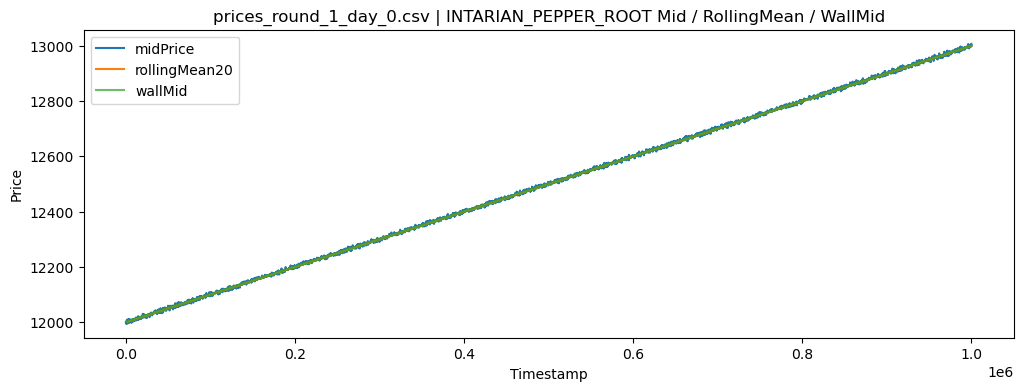

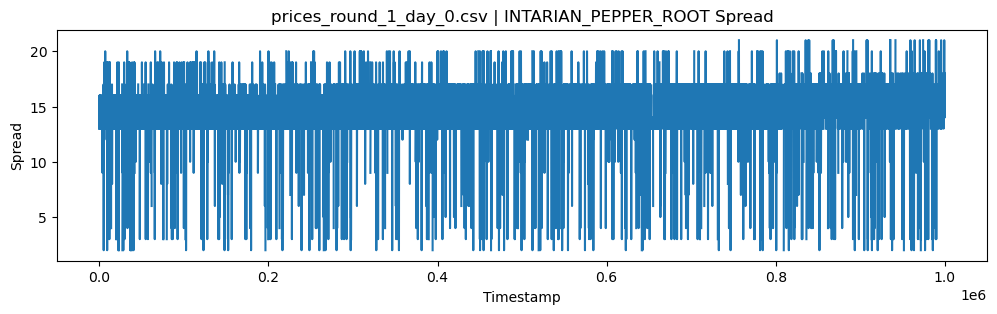

In [7]:
# Plot one selected day
plotFileName = round1PriceFiles[-1]   # change this and rerun to inspect another day
plotWork = allWork[allWork["fileName"] == plotFileName].copy()

print("Plotting:", plotFileName)

for product in sorted(plotWork["product"].dropna().unique()):
    productDf = plotWork[plotWork["product"] == product].copy().sort_values("timestamp")

    plt.figure(figsize=(12, 4))
    plt.plot(productDf["timestamp"], productDf["midPrice"], label="midPrice")
    plt.plot(productDf["timestamp"], productDf["rollingMean20"], label="rollingMean20")
    if "wallMid" in productDf.columns and productDf["wallMid"].notna().any():
        plt.plot(productDf["timestamp"], productDf["wallMid"], label="wallMid", alpha=0.7)
    plt.title(f"{plotFileName} | {product} Mid / RollingMean / WallMid")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 3))
    plt.plot(productDf["timestamp"], productDf["spread"])
    plt.title(f"{plotFileName} | {product} Spread")
    plt.xlabel("Timestamp")
    plt.ylabel("Spread")
    plt.show()


## 7. Compare one product across all days
Set `productToCompare` below and rerun this cell to see the same product across every loaded day.


Product: INTARIAN_PEPPER_ROOT
Files: ['prices_round_1_day_-2.csv', 'prices_round_1_day_-1.csv', 'prices_round_1_day_0.csv']


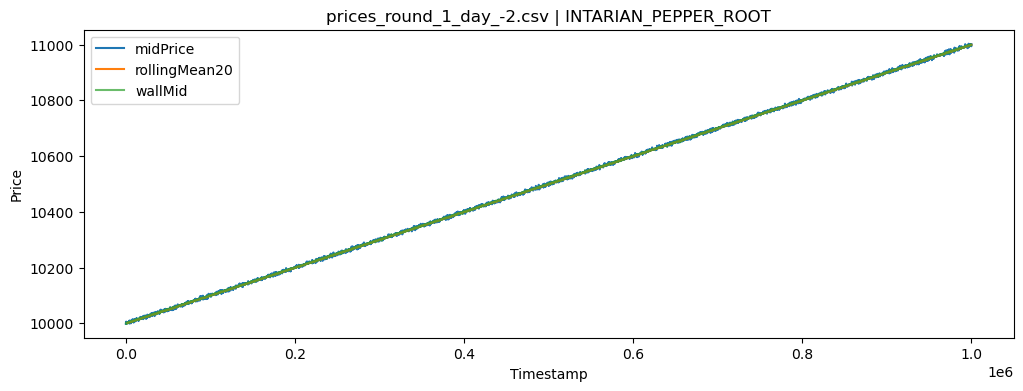

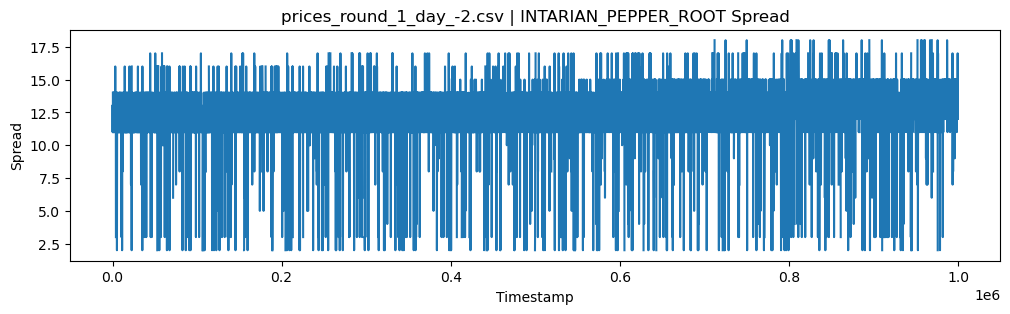

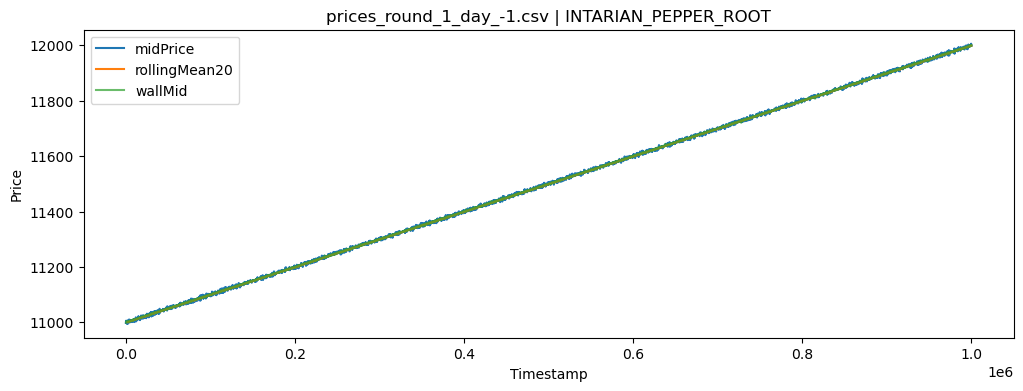

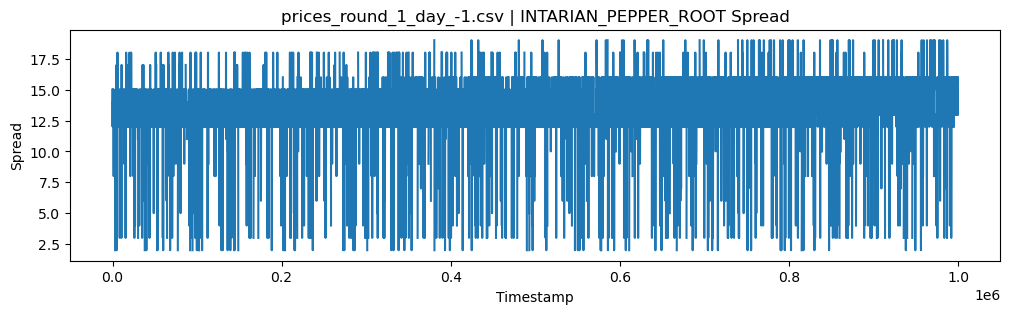

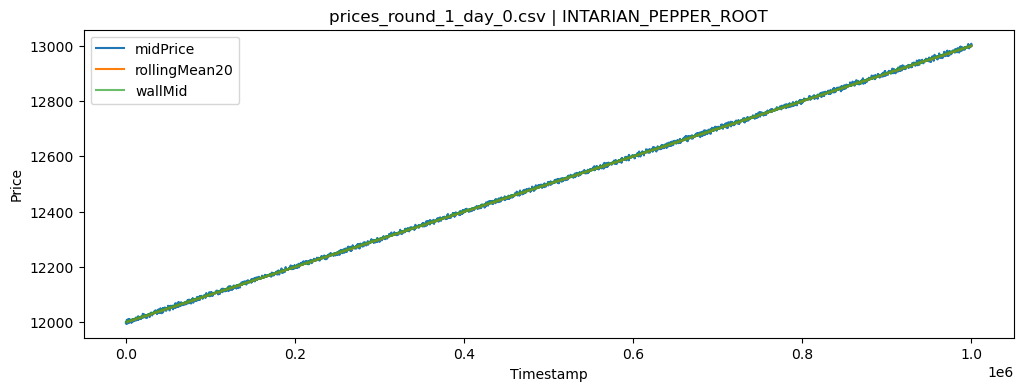

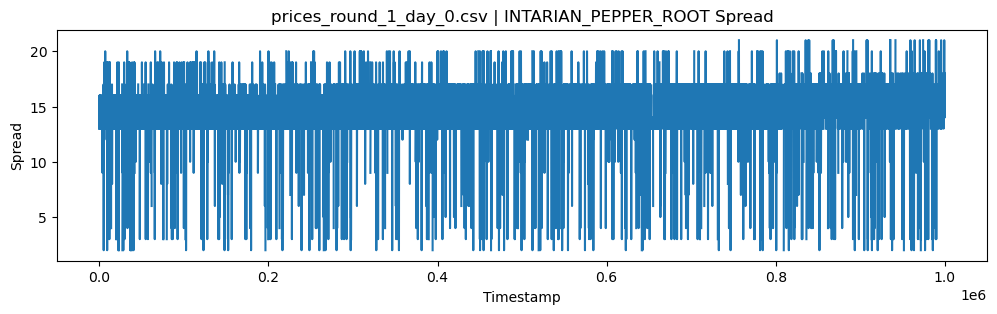

In [8]:
# Compare one product across all days
productToCompare = "INTARIAN_PEPPER_ROOT"   # change and rerun for another product
compareDf = allWork[allWork["product"] == productToCompare].copy().sort_values(["day", "timestamp"])

availableFiles = compareDf["fileName"].dropna().unique().tolist()
print("Product:", productToCompare)
print("Files:", availableFiles)

for fileName in availableFiles:
    productDf = compareDf[compareDf["fileName"] == fileName].copy().sort_values("timestamp")

    plt.figure(figsize=(12, 4))
    plt.plot(productDf["timestamp"], productDf["midPrice"], label="midPrice")
    plt.plot(productDf["timestamp"], productDf["rollingMean20"], label="rollingMean20")
    if "wallMid" in productDf.columns and productDf["wallMid"].notna().any():
        plt.plot(productDf["timestamp"], productDf["wallMid"], label="wallMid", alpha=0.7)
    plt.title(f"{fileName} | {productToCompare}")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 3))
    plt.plot(productDf["timestamp"], productDf["spread"])
    plt.title(f"{fileName} | {productToCompare} Spread")
    plt.xlabel("Timestamp")
    plt.ylabel("Spread")
    plt.show()


In [9]:
# Pepper-specific regression diagnostics across all loaded days
pepper = "INTARIAN_PEPPER_ROOT"
pepperWindows = [50, 100, 150]
pepperFramesByFile = {}
pepperDiagRows = []

for fileName in round1PriceFiles:
    pepperDf = allWork[(allWork["fileName"] == fileName) & (allWork["product"] == pepper)].copy().sort_values("timestamp").reset_index(drop=True)

    if len(pepperDf) == 0:
        continue

    pepperDf = add_regression_fairs(pepperDf, windows=pepperWindows)
    pepperFramesByFile[fileName] = pepperDf

    pepperDf["jumpAbs"] = pepperDf["midPrice"].diff().abs()

    for window in pepperWindows:
        pepperDiagRows.append({
            "fileName": fileName,
            "day": pepperDf["day"].iloc[0],
            "window": window,
            "rows": len(pepperDf),
            "residual_std": pepperDf[f"regResidual{window}"].std(),
            "residual_mean": pepperDf[f"regResidual{window}"].mean(),
            "residual_z_next_return_corr": pepperDf[f"regResidualZ{window}"].corr(pepperDf["nextReturn1"]),
            "slope_next_return_corr": pepperDf[f"regSlope{window}"].corr(pepperDf["nextReturn1"]),
            "abs_diff_ge_3": (pepperDf["jumpAbs"] >= 3).sum(),
            "abs_diff_ge_5": (pepperDf["jumpAbs"] >= 5).sum(),
            "abs_diff_ge_8": (pepperDf["jumpAbs"] >= 8).sum(),
            "abs_diff_ge_10": (pepperDf["jumpAbs"] >= 10).sum(),
        })

pepperDiagDf = pd.DataFrame(pepperDiagRows).sort_values(["day", "window"]).reset_index(drop=True)
pepperDiagDf


,fileName,day,window,rows,residual_std,residual_mean,residual_z_next_return_corr,slope_next_return_corr,abs_diff_ge_3,abs_diff_ge_5,abs_diff_ge_8,abs_diff_ge_10
0,prices_round_1_day_-2.csv,-2,50,10000,2.081805,0.099951,-0.669148,-0.002767,2112,1424,215,65
1,prices_round_1_day_-2.csv,-2,100,10000,2.047061,0.099926,-0.680331,-0.001536,2112,1424,215,65
2,prices_round_1_day_-2.csv,-2,150,10000,2.038332,0.099451,-0.683393,0.000052,2112,1424,215,65
3,prices_round_1_day_-1.csv,-1,50,10000,2.301667,0.099950,-0.670437,-0.004091,2286,1657,320,91
4,prices_round_1_day_-1.csv,-1,100,10000,2.260124,0.100864,-0.682893,-0.001818,2286,1657,320,91
5,prices_round_1_day_-1.csv,-1,150,10000,2.248187,0.098010,-0.686182,-0.003089,2286,1657,320,91
6,prices_round_1_day_0.csv,0,50,10000,2.443658,0.100155,-0.672544,-0.001102,2273,1792,427,183
7,prices_round_1_day_0.csv,0,100,10000,2.398208,0.101129,-0.685587,0.000697,2273,1792,427,183
8,prices_round_1_day_0.csv,0,150,10000,2.386169,0.100391,-0.688638,0.000542,2273,1792,427,183


In [10]:
# Osmium-specific diagnostics across all loaded days
osmium = "ASH_COATED_OSMIUM"
osmiumSignalRows = []
osmiumFramesByFile = {}

for fileName in round1PriceFiles:
    osmiumDf = allWork[(allWork["fileName"] == fileName) & (allWork["product"] == osmium)].copy().sort_values("timestamp").reset_index(drop=True)

    if len(osmiumDf) == 0:
        continue

    osmiumDf["ma20"] = osmiumDf["midPrice"].rolling(20, min_periods=20).mean()
    osmiumDf["ma50"] = osmiumDf["midPrice"].rolling(50, min_periods=50).mean()
    osmiumDf["ma100"] = osmiumDf["midPrice"].rolling(100, min_periods=100).mean()
    osmiumDf["trend20_50"] = osmiumDf["ma20"] - osmiumDf["ma50"]
    osmiumDf["trend20_100"] = osmiumDf["ma20"] - osmiumDf["ma100"]

    osmiumFramesByFile[fileName] = osmiumDf

    osmiumSignalRows.append({
        "fileName": fileName,
        "day": osmiumDf["day"].iloc[0],
        "rows": len(osmiumDf),
        "ret_autocorr_1": osmiumDf["return1"].autocorr(lag=1),
        "ret_autocorr_2": osmiumDf["return1"].autocorr(lag=2),
        "mom5_next_ret_corr": osmiumDf["momentum5"].corr(osmiumDf["nextReturn1"]),
        "mom10_next_ret_corr": osmiumDf["momentum10"].corr(osmiumDf["nextReturn1"]),
        "trend20_50_next_ret_corr": osmiumDf["trend20_50"].corr(osmiumDf["nextReturn1"]),
        "trend20_100_next_ret_corr": osmiumDf["trend20_100"].corr(osmiumDf["nextReturn1"]),
        "imbalance_next_ret_corr": osmiumDf["imbalance"].corr(osmiumDf["nextReturn1"]) if "imbalance" in osmiumDf.columns else np.nan,
    })

osmiumSignalDf = pd.DataFrame(osmiumSignalRows).sort_values("day").reset_index(drop=True)
osmiumSignalDf


,fileName,day,rows,ret_autocorr_1,ret_autocorr_2,mom5_next_ret_corr,mom10_next_ret_corr,trend20_50_next_ret_corr,trend20_100_next_ret_corr,imbalance_next_ret_corr
0,prices_round_1_day_-2.csv,-2,10000,-0.498808,0.011400,-0.495708,-0.482113,-0.065050,-0.051326,0.371805
1,prices_round_1_day_-1.csv,-1,10000,-0.497211,-0.001686,-0.492117,-0.488888,-0.067158,-0.054802,0.391263
2,prices_round_1_day_0.csv,0,10000,-0.487015,-0.015297,-0.483272,-0.482533,-0.063102,-0.049428,0.379342


In [11]:
# Edge frequency checks against multiple fair choices
edgeRows = []

for (fileName, day, product), productDf in allWork.groupby(["fileName", "day", "product"], sort=True):
    productDf = productDf.sort_values("timestamp").reset_index(drop=True)
    fairDict = fair_candidates_for_product(
        productDf=productDf,
        product=product,
        pepperFramesByFile=pepperFramesByFile,
        fileName=fileName,
    )

    for fairName, fairSeries in fairDict.items():
        fairSeries = fairSeries.astype(float)

        edgeRows.append({
            "fileName": fileName,
            "day": day,
            "product": product,
            "fair_name": fairName,
            "ask_le_fair_minus_1_freq": (productDf["ask_price_1"] <= fairSeries - 1).mean(),
            "ask_le_fair_minus_2_freq": (productDf["ask_price_1"] <= fairSeries - 2).mean(),
            "bid_ge_fair_plus_1_freq": (productDf["bid_price_1"] >= fairSeries + 1).mean(),
            "bid_ge_fair_plus_2_freq": (productDf["bid_price_1"] >= fairSeries + 2).mean(),
            "spread_le_2_freq": (productDf["spread"] <= 2).mean(),
            "spread_ge_4_freq": (productDf["spread"] >= 4).mean(),
        })

edgeDf = pd.DataFrame(edgeRows).sort_values(["product", "day", "fair_name"]).reset_index(drop=True)
edgeDf


,fileName,day,product,fair_name,ask_le_fair_minus_1_freq,ask_le_fair_minus_2_freq,bid_ge_fair_plus_1_freq,bid_ge_fair_plus_2_freq,spread_le_2_freq,spread_ge_4_freq
0,prices_round_1_day_-2.csv,-2,ASH_COATED_OSMIUM,microprice,0.0000,0.0000,0.0000,0.0000,0.0000,0.9187
1,prices_round_1_day_-2.csv,-2,ASH_COATED_OSMIUM,midPrice,0.0000,0.0000,0.0000,0.0000,0.0000,0.9187
2,prices_round_1_day_-2.csv,-2,ASH_COATED_OSMIUM,rollingMean20,0.0103,0.0072,0.0085,0.0034,0.0000,0.9187
3,prices_round_1_day_-2.csv,-2,ASH_COATED_OSMIUM,wallMid,0.0100,0.0083,0.0093,0.0025,0.0000,0.9187
4,prices_round_1_day_-1.csv,-1,ASH_COATED_OSMIUM,microprice,0.0000,0.0000,0.0000,0.0000,0.0000,0.9225
5,prices_round_1_day_-1.csv,-1,ASH_COATED_OSMIUM,midPrice,0.0000,0.0000,0.0000,0.0000,0.0000,0.9225
6,prices_round_1_day_-1.csv,-1,ASH_COATED_OSMIUM,rollingMean20,0.0119,0.0067,0.0086,0.0030,0.0000,0.9225
7,prices_round_1_day_-1.csv,-1,ASH_COATED_OSMIUM,wallMid,0.0116,0.0099,0.0110,0.0018,0.0000,0.9225
8,prices_round_1_day_0.csv,0,ASH_COATED_OSMIUM,microprice,0.0000,0.0000,0.0000,0.0000,0.0000,0.9232
9,prices_round_1_day_0.csv,0,ASH_COATED_OSMIUM,midPrice,0.0000,0.0000,0.0000,0.0000,0.0000,0.9232


In [12]:
# Passive quote diagnostic with multiple fair choices
quoteRows = []

for (fileName, day, product), productDf in allWork.groupby(["fileName", "day", "product"], sort=True):
    productDf = productDf.sort_values("timestamp").reset_index(drop=True)
    fairDict = fair_candidates_for_product(
        productDf=productDf,
        product=product,
        pepperFramesByFile=pepperFramesByFile,
        fileName=fileName,
    )

    wouldBidAt = productDf["bid_price_1"] + 1
    wouldAskAt = productDf["ask_price_1"] - 1

    for fairName, fairSeries in fairDict.items():
        fairSeries = fairSeries.astype(float)

        quoteRows.append({
            "fileName": fileName,
            "day": day,
            "product": product,
            "fair_name": fairName,
            "avg_best_bid": productDf["bid_price_1"].mean(),
            "avg_best_ask": productDf["ask_price_1"].mean(),
            "avg_quote_bid": wouldBidAt.mean(),
            "avg_quote_ask": wouldAskAt.mean(),
            "quote_cross_rate": (wouldBidAt >= wouldAskAt).mean(),
            "avg_bid_edge_vs_fair": (fairSeries - wouldBidAt).mean(),
            "avg_ask_edge_vs_fair": (wouldAskAt - fairSeries).mean(),
        })

quoteDf = pd.DataFrame(quoteRows).sort_values(["product", "day", "fair_name"]).reset_index(drop=True)
quoteDf


,fileName,day,product,fair_name,avg_best_bid,avg_best_ask,avg_quote_bid,avg_quote_ask,quote_cross_rate,avg_bid_edge_vs_fair,avg_ask_edge_vs_fair
0,prices_round_1_day_-2.csv,-2,ASH_COATED_OSMIUM,microprice,9990.105247,10006.230954,9991.105247,10005.230954,0.0000,7.031551,7.118226
1,prices_round_1_day_-2.csv,-2,ASH_COATED_OSMIUM,midPrice,9990.105247,10006.230954,9991.105247,10005.230954,0.0000,6.737979,6.742016
2,prices_round_1_day_-2.csv,-2,ASH_COATED_OSMIUM,rollingMean20,9990.105247,10006.230954,9991.105247,10005.230954,0.0000,7.064446,7.049098
3,prices_round_1_day_-2.csv,-2,ASH_COATED_OSMIUM,wallMid,9990.105247,10006.230954,9991.105247,10005.230954,0.0000,7.057364,7.092413
4,prices_round_1_day_-1.csv,-1,ASH_COATED_OSMIUM,microprice,9992.738180,10008.925984,9993.738180,10007.925984,0.0000,7.089847,7.101481
5,prices_round_1_day_-1.csv,-1,ASH_COATED_OSMIUM,midPrice,9992.738180,10008.925984,9993.738180,10007.925984,0.0000,6.777807,6.774568
6,prices_round_1_day_-1.csv,-1,ASH_COATED_OSMIUM,rollingMean20,9992.738180,10008.925984,9993.738180,10007.925984,0.0000,7.070286,7.083501
7,prices_round_1_day_-1.csv,-1,ASH_COATED_OSMIUM,wallMid,9992.738180,10008.925984,9993.738180,10007.925984,0.0000,7.114851,7.076477
8,prices_round_1_day_0.csv,0,ASH_COATED_OSMIUM,microprice,9993.521599,10009.705234,9994.521599,10008.705234,0.0000,7.082547,7.101920
9,prices_round_1_day_0.csv,0,ASH_COATED_OSMIUM,midPrice,9993.521599,10009.705234,9994.521599,10008.705234,0.0000,6.776361,6.773125


## 8. Pair relationship checks
Useful once multiple products appear linked.

In [13]:
# Pair relationship checks (run per file so timestamp resets do not mix days)
corrByFile = {}

for fileName in round1PriceFiles:
    tmp = allWork[allWork["fileName"] == fileName].copy()
    pivotMid = tmp.pivot_table(index="timestamp", columns="product", values="midPrice", aggfunc="last")
    corrByFile[fileName] = pivotMid.corr()

for fileName, corrDf in corrByFile.items():
    print("\n", fileName)
    display(corrDf)



 prices_round_1_day_-1.csv


product,ASH_COATED_OSMIUM,INTARIAN_PEPPER_ROOT
product,,
ASH_COATED_OSMIUM,1.000000,-0.056468
INTARIAN_PEPPER_ROOT,-0.056468,1.000000



 prices_round_1_day_-2.csv


product,ASH_COATED_OSMIUM,INTARIAN_PEPPER_ROOT
product,,
ASH_COATED_OSMIUM,1.000000,-0.077276
INTARIAN_PEPPER_ROOT,-0.077276,1.000000



 prices_round_1_day_0.csv


product,ASH_COATED_OSMIUM,INTARIAN_PEPPER_ROOT
product,,
ASH_COATED_OSMIUM,1.000000,0.078492
INTARIAN_PEPPER_ROOT,0.078492,1.000000


## 9. Manual classification notes
After you inspect the tables and plots, classify each product:
- anchored / stable
- mean reverting
- trending
- linked to another product
- model-based / derivative
- microstructure-heavy


In [14]:
# Write your notes here as Python comments or plain strings.
notes = {
    # "INTARIAN_PEPPER_ROOT": "Example: looks drift-aware, regression fair seems strongest on day -1 and day 0",
    # "ASH_COATED_OSMIUM": "Example: short-horizon mean reversion / anchored microstructure product",
}
notes


{}

## 10. Next step
Once you decide the strategy family from this notebook, implement only the surviving logic in `trader.py`.